In [ ]:
import numpy as np

# Path to your file
path = r"C:\Users\fathi\Desktop\Rest_eeg_ds004504-download\xai-captum_2\xai-captum\class1_win4_ol0\xai-allruns\averaged_across_runs\overall_averaged_importance.npz"

# Load the npz file
data = np.load(path, allow_pickle=True)

# Print the keys inside the npz archive
print("Keys inside NPZ file:", data.files)

# Inspect each key
for key in data.files:
    print(f"\n--- {key} ---")
    print("Type:", type(data[key]))
    print("Shape:", getattr(data[key], "shape", None))
    print("Data preview:", data[key])


In [ ]:
import numpy as np
data = np.load( r"C:\Users\fathi\Desktop\Rest_eeg_ds004504-download\xai-captum_2\xai-captum\class1_win4_ol0\xai-allruns\averaged_across_runs\overall_averaged_importance.npz", allow_pickle=True)
print(data.files)

for k in data.files:
    print(k, type(data[k]), getattr(data[k], "shape", None))


In [9]:
import numpy as np
import pandas as pd
import os

# Path to your .npz file
path = r'C:\Users\fathi\Desktop\Rest_eeg_ds004504-download\xai_saliency\xai_saliency_allruns\class2_win6_ol50\averaged_across_runs\overall_averaged_importance.npz'
# Output CSV path
save_path = r'C:\Users\fathi\Desktop\Rest_eeg_ds004504-download\xai_saliency\xai_saliency_allruns\class2_win6_ol50\overall_averaged_importance.csv'

# Load NPZ
data = np.load(path, allow_pickle=True)

rows = {}

for key in data.files:
    arr = data[key]

    # Convert scalar to list
    if arr.shape == ():
        rows[key] = [arr.item()]
    else:
        rows[key] = arr.tolist()

# Convert to DataFrame and save
df = pd.DataFrame.from_dict(rows, orient='index')
df.to_csv(save_path, header=False)

print("Saved CSV to:", save_path)


Saved CSV to: C:\Users\fathi\Desktop\Rest_eeg_ds004504-download\xai_saliency\xai_saliency_allruns\class2_win6_ol50\overall_averaged_importance.csv


In [ ]:
import os
import pandas as pd
import numpy as np

# Base directory
base_dir = r"C:\Users\fathi\Desktop\Rest_eeg_ds004504-download\xai-captum_2\xai-captum"

# Expected folders for each class
settings = [
    "win4_ol0",
    "win4_ol50",
    "win6_ol0",
    "win6_ol50"
]

# Features to average (exclude num_runs_averaged and successful_runs)
features_to_average = [
    "overall_node_importance",
    "overall_alpha_importance",
    "overall_beta_importance",
    "class_0_node_importance",
    "class_1_node_importance",
    "class_0_alpha_importance",
    "class_1_alpha_importance",
    "class_0_beta_importance",
    "class_1_beta_importance"
]

def load_class_files(class_id):
    """Load the 4 CSV files for a given class (1 or 2)."""
    dataframes = []
    found_files = []
    missing_files = []
    
    for s in settings:
        folder = f"class{class_id}_{s}"
        
        # Try both "xai-allruns" and "xai-allrun" (handle typo)
        full_path_plural = os.path.join(base_dir, folder, "xai-allruns", "overall_averaged_importance.csv")
        full_path_singular = os.path.join(base_dir, folder, "xai-allrun", "overall_averaged_importance.csv")
        
        full_path = None
        if os.path.exists(full_path_plural):
            full_path = full_path_plural
        elif os.path.exists(full_path_singular):
            full_path = full_path_singular
        else:
            missing_files.append(folder)
            print(f"⚠ Missing: {folder} (checked both xai-allruns and xai-allrun)")
            continue
        
        # Read CSV with first column as index AND first row as header
        df = pd.read_csv(full_path, index_col=0, header=0)
        
        # Filter to only the features we want to average
        df_filtered = df.loc[features_to_average]
        
        # Ensure all data is numeric
        df_filtered = df_filtered.apply(pd.to_numeric, errors='coerce')
        
        dataframes.append(df_filtered)
        found_files.append(folder)
        print(f"✓ Found: {folder}")
        print(f"  Shape: {df_filtered.shape} (features × nodes)")

    print(f"\nClass {class_id} Summary: {len(found_files)}/{len(settings)} files found\n")
    return dataframes

def average_class(class_id):
    """Average the 4 CSV files for class1 or class2."""
    print(f"{'='*60}")
    print(f"Processing Class {class_id}")
    print(f"{'='*60}")
    
    dfs = load_class_files(class_id)

    if len(dfs) == 0:
        raise ValueError(f"No CSV files found for class {class_id}.")

    # Check that all dataframes have the same shape
    shapes = [df.shape for df in dfs]
    print(f"DataFrames to average: {len(dfs)}")
    print(f"Shapes: {shapes}")
    
    if len(set(shapes)) > 1:
        print("⚠ WARNING: DataFrames have different shapes!")
        for i, (s, df) in enumerate(zip(settings[:len(dfs)], dfs)):
            print(f"  {s}: {df.shape}")
    
    # Average across the 4 dataframes (element-wise average)
    # Each dataframe is 9 features × 19 nodes, result will be same shape
    averaged = sum(dfs) / len(dfs)

    # Save result
    save_path = os.path.join(base_dir, f"class{class_id}_averaged.csv")
    averaged.to_csv(save_path)
    print(f"\n✔ Saved: {save_path}")
    print(f"  Shape: {averaged.shape} (9 features × 19 nodes)")
    print(f"  Features: {list(averaged.index)}")
    print(f"  Number of nodes: {averaged.shape[1]}")
    print(f"\nFirst 3 columns of averaged data:")
    print(averaged.iloc[:, :3])
    print()

    return averaged


# ---- Run for class1 and class2 ----
print("\n" + "="*60)
print("AVERAGING XAI IMPORTANCE SCORES")
print("="*60 + "\n")

try:
    avg_class1 = average_class(1)
    avg_class2 = average_class(2)
    
    print("="*60)
    print("DONE ✓")
    print("="*60)
    print(f"\nOutput files:")
    print(f"  • class1_averaged.csv")
    print(f"  • class2_averaged.csv")
    print(f"\nFinal shapes:")
    print(f"  • Class 1: {avg_class1.shape} (9 features × 19 nodes)")
    print(f"  • Class 2: {avg_class2.shape} (9 features × 19 nodes)")
    
except Exception as e:
    print(f"\n❌ ERROR: {e}")
    import traceback
    traceback.print_exc()

In [ ]:
import os
import pandas as pd
import numpy as np

# Base directory
base_dir = r"C:\Users\fathi\Desktop\Rest_eeg_ds004504-download\xai-captum_2\xai-captum"

# Expected folders for each class
settings = [
    "win4_ol0",
    "win4_ol50",
    "win6_ol0",
    "win6_ol50"
]

def inspect_csv_structure(class_id):
    """Inspect the first CSV file to see its actual structure."""
    for s in settings:
        folder = f"class{class_id}_{s}"
        
        # Try both paths
        full_path_plural = os.path.join(base_dir, folder, "xai-allruns", "overall_averaged_importance.csv")
        full_path_singular = os.path.join(base_dir, folder, "xai-allrun", "overall_averaged_importance.csv")
        
        full_path = None
        if os.path.exists(full_path_plural):
            full_path = full_path_plural
        elif os.path.exists(full_path_singular):
            full_path = full_path_singular
        else:
            continue
        
        print(f"Inspecting: {folder}")
        print(f"Path: {full_path}\n")
        
        # Read without specifying index
        df_raw = pd.read_csv(full_path, nrows=15)
        print("Raw CSV (first 15 rows):")
        print(df_raw)
        print("\n" + "="*80 + "\n")
        
        # Read with index_col=0
        df = pd.read_csv(full_path, index_col=0, header=0)
        print(f"DataFrame shape: {df.shape}")
        print(f"Index (row names): {list(df.index)}")
        print(f"Columns (node names): {list(df.columns)}")
        print("\nFirst few rows:")
        print(df.head())
        
        return  # Only check the first found file

# Inspect class 1
inspect_csv_structure(1)

In [12]:
import os
import pandas as pd
import numpy as np

# Base directory
base_dir = r'C:\Users\fathi\Desktop\Rest_eeg_ds004504-download\xai_saliency\xai_saliency_allruns'

# Expected folders for each class
settings = [
    "win4_ol0",
    "win4_ol50",
    "win6_ol0",
    "win6_ol50"
]

# Features to average (exclude num_runs_averaged and successful_runs)
features_to_average = [
    "overall_node_importance",
    "overall_alpha_importance",
    "overall_beta_importance",
    "class_0_node_importance",
    "class_1_node_importance",
    "class_0_alpha_importance",
    "class_1_alpha_importance",
    "class_0_beta_importance",
    "class_1_beta_importance"
]

def load_class_files(class_id):
    """Load the 4 CSV files for a given class (1 or 2)."""
    dataframes = []
    found_files = []
    missing_files = []
    
    for s in settings:
        folder = f"class{class_id}_{s}"
        
        # Try both "xai-allruns" and "xai-allrun" (handle typo)
        full_path_plural = os.path.join(base_dir, folder, "overall_averaged_importance.csv")
        full_path_singular = os.path.join(base_dir, folder, "xai_saliency_allruns", "overall_averaged_importance.csv")
        
        full_path = None
        if os.path.exists(full_path_plural):
            full_path = full_path_plural
        elif os.path.exists(full_path_singular):
            full_path = full_path_singular
        else:
            missing_files.append(folder)
            print(f"⚠ Missing: {folder} (checked both xai-allruns and xai-allrun)")
            continue
        
        # Read CSV with NO header (header=None), first column becomes index
        df = pd.read_csv(full_path, header=None)
        
        # Set first column as index (feature names)
        df = df.set_index(0)
        df.index.name = 'feature'
        
        # Column names are now numeric (0, 1, 2, ..., 18 for 19 nodes)
        # Rename them to be clearer
        df.columns = [f'node_{i}' for i in range(len(df.columns))]
        
        # Filter to only the features we want to average
        df_filtered = df.loc[features_to_average]
        
        # Ensure all data is numeric
        df_filtered = df_filtered.apply(pd.to_numeric, errors='coerce')
        
        dataframes.append(df_filtered)
        found_files.append(folder)
        print(f"✓ Found: {folder}")
        print(f"  Shape: {df_filtered.shape} (features × nodes)")

    print(f"\nClass {class_id} Summary: {len(found_files)}/{len(settings)} files found\n")
    return dataframes

def average_class(class_id):
    """Average the 4 CSV files for class1 or class2."""
    print(f"{'='*60}")
    print(f"Processing Class {class_id}")
    print(f"{'='*60}")
    
    dfs = load_class_files(class_id)

    if len(dfs) == 0:
        raise ValueError(f"No CSV files found for class {class_id}.")

    # Check that all dataframes have the same shape
    shapes = [df.shape for df in dfs]
    print(f"DataFrames to average: {len(dfs)}")
    print(f"Shapes: {shapes}")
    
    if len(set(shapes)) > 1:
        print("⚠ WARNING: DataFrames have different shapes!")
        for i, (s, df) in enumerate(zip(settings[:len(dfs)], dfs)):
            print(f"  {s}: {df.shape}")
    
    # Average across the 4 dataframes (element-wise average)
    # Each dataframe is 9 features × 19 nodes, result will be same shape
    averaged = sum(dfs) / len(dfs)

    # Save result
    save_path = os.path.join(base_dir, f"class{class_id}_averaged.csv")
    averaged.to_csv(save_path)
    print(f"\n✔ Saved: {save_path}")
    print(f"  Shape: {averaged.shape} (9 features × {averaged.shape[1]} nodes)")
    print(f"  Features: {list(averaged.index)}")
    print(f"\nFirst 3 nodes of averaged data:")
    print(averaged.iloc[:, :3])
    print()

    return averaged


# ---- Run for class1 and class2 ----
print("\n" + "="*60)
print("AVERAGING XAI IMPORTANCE SCORES")
print("="*60 + "\n")

try:
    avg_class1 = average_class(1)
    avg_class2 = average_class(2)
    
    print("="*60)
    print("DONE ✓")
    print("="*60)
    print(f"\nOutput files:")
    print(f"  • class1_averaged.csv")
    print(f"  • class2_averaged.csv")
    print(f"\nFinal shapes:")
    print(f"  • Class 1: {avg_class1.shape} (9 features × {avg_class1.shape[1]} nodes)")
    print(f"  • Class 2: {avg_class2.shape} (9 features × {avg_class2.shape[1]} nodes)")
    
except Exception as e:
    print(f"\n❌ ERROR: {e}")
    import traceback
    traceback.print_exc()


AVERAGING XAI IMPORTANCE SCORES

Processing Class 1
✓ Found: class1_win4_ol0
  Shape: (9, 19) (features × nodes)
✓ Found: class1_win4_ol50
  Shape: (9, 19) (features × nodes)
✓ Found: class1_win6_ol0
  Shape: (9, 19) (features × nodes)
✓ Found: class1_win6_ol50
  Shape: (9, 19) (features × nodes)

Class 1 Summary: 4/4 files found

DataFrames to average: 4
Shapes: [(9, 19), (9, 19), (9, 19), (9, 19)]

✔ Saved: C:\Users\fathi\Desktop\Rest_eeg_ds004504-download\xai_saliency\xai_saliency_allruns\class1_averaged.csv
  Shape: (9, 19) (9 features × 19 nodes)
  Features: ['overall_node_importance', 'overall_alpha_importance', 'overall_beta_importance', 'class_0_node_importance', 'class_1_node_importance', 'class_0_alpha_importance', 'class_1_alpha_importance', 'class_0_beta_importance', 'class_1_beta_importance']

First 3 nodes of averaged data:
                            node_0    node_1    node_2
feature                                               
overall_node_importance   0.613332  0.3

COMPARATIVE ANALYSIS: CN vs FTD (Group 1) vs CN vs AD (Group 2)

Group 1 (CN vs FTD):
  Shape: (9, 19)

Group 2 (CN vs AD):
  Shape: (9, 19)

TOP 5 LARGEST ABSOLUTE DIFFERENCES

Top 5 Feature-Node pairs with largest absolute differences:
(Between CN vs FTD group and CN vs AD group)
1. class_0_node_importance @ node_0
   CN vs FTD: 0.667169
   CN vs AD:  0.174213
   Difference: 0.492955

2. overall_alpha_importance @ node_0
   CN vs FTD: 0.642870
   CN vs AD:  0.196511
   Difference: 0.446359

3. class_0_alpha_importance @ node_0
   CN vs FTD: 0.663527
   CN vs AD:  0.220005
   Difference: 0.443522

4. overall_node_importance @ node_0
   CN vs FTD: 0.613332
   CN vs AD:  0.172745
   Difference: 0.440587

5. class_1_alpha_importance @ node_0
   CN vs FTD: 0.616824
   CN vs AD:  0.177585
   Difference: 0.439238

TOP 5 LARGEST RELATIVE DIFFERENCES (Percentage)

Top 5 Feature-Node pairs with largest relative differences:
1. class_0_node_importance @ node_0
   CN vs FTD: 0.667169
   CN vs AD

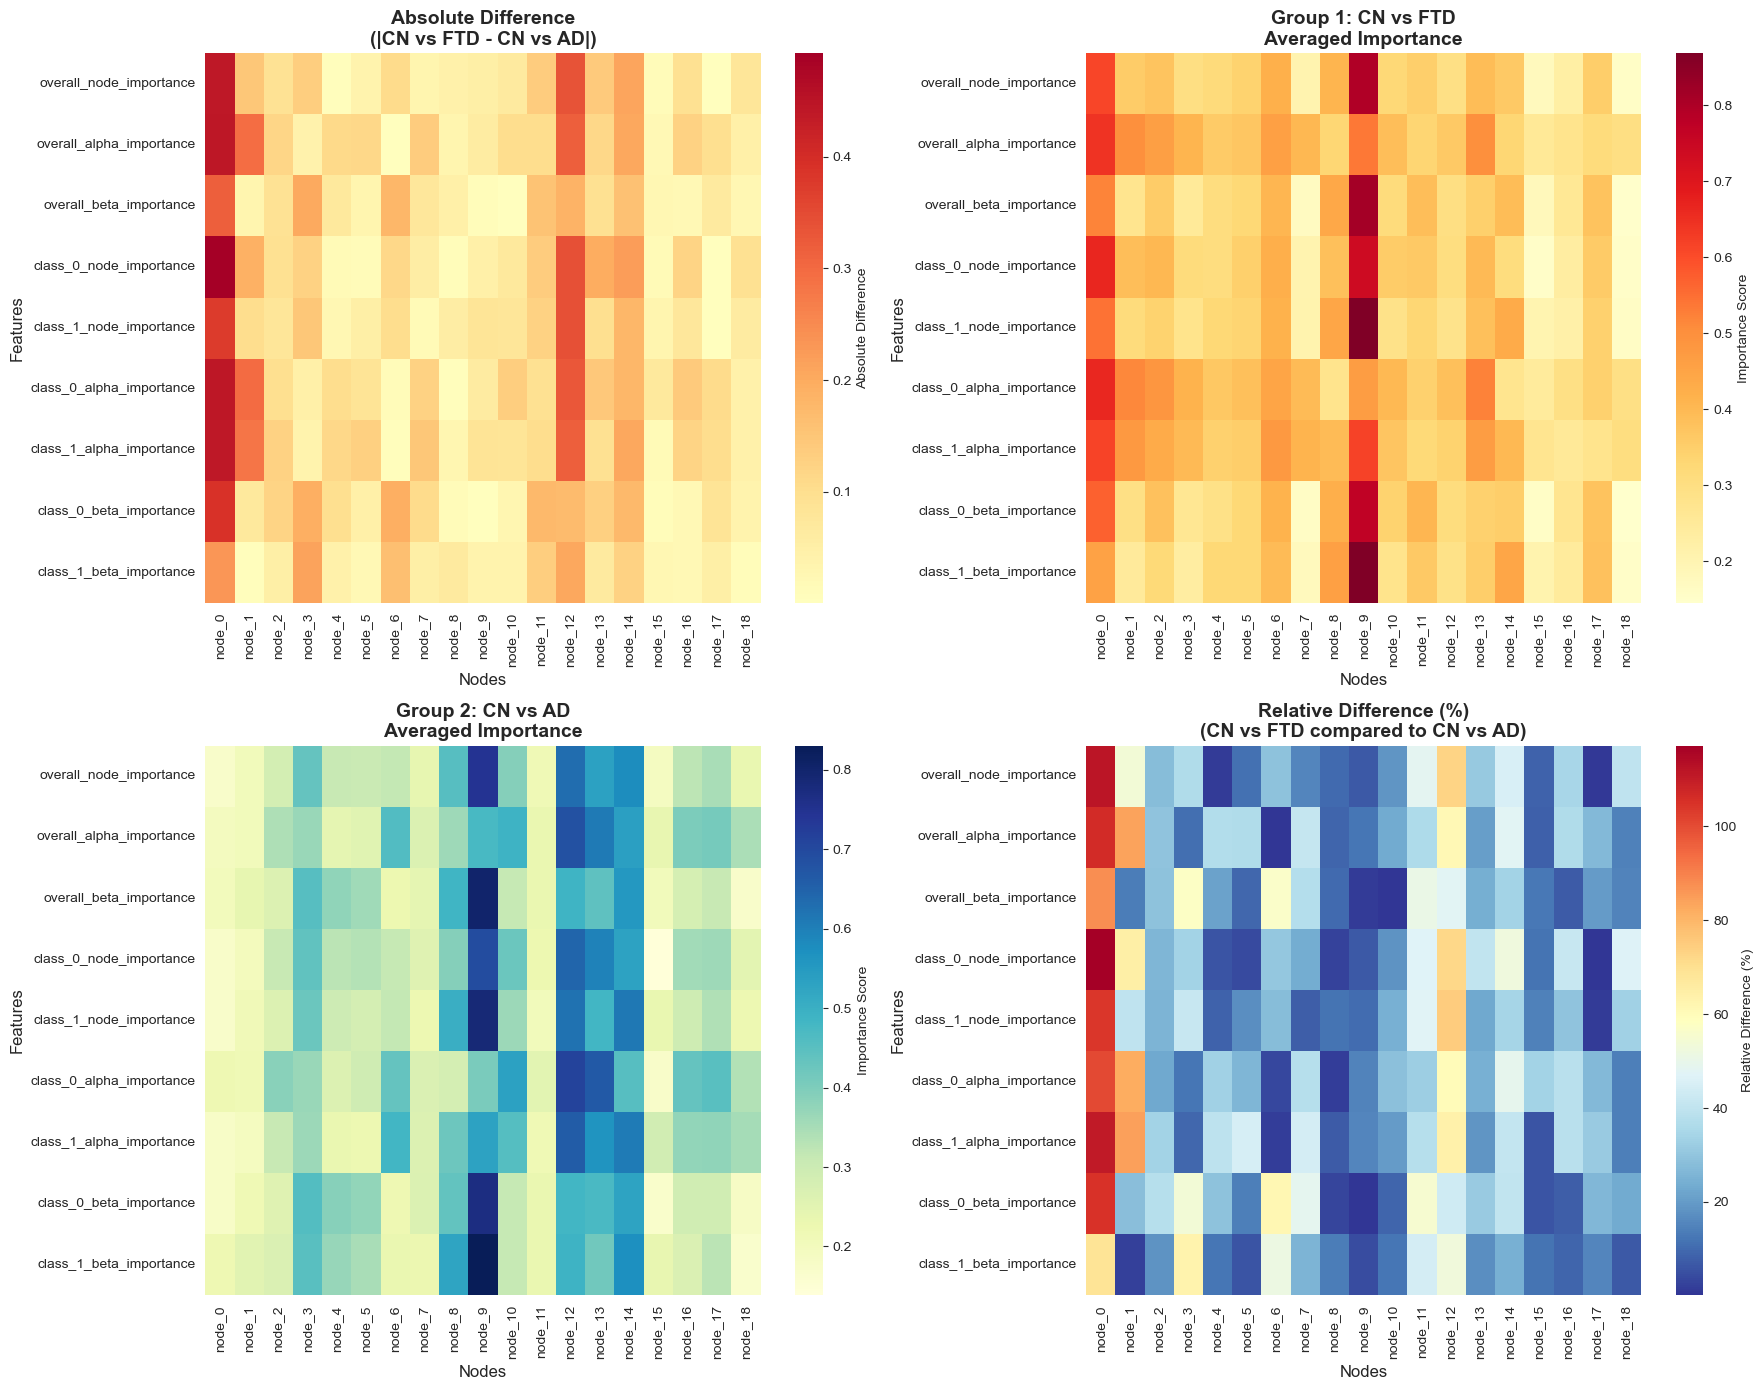

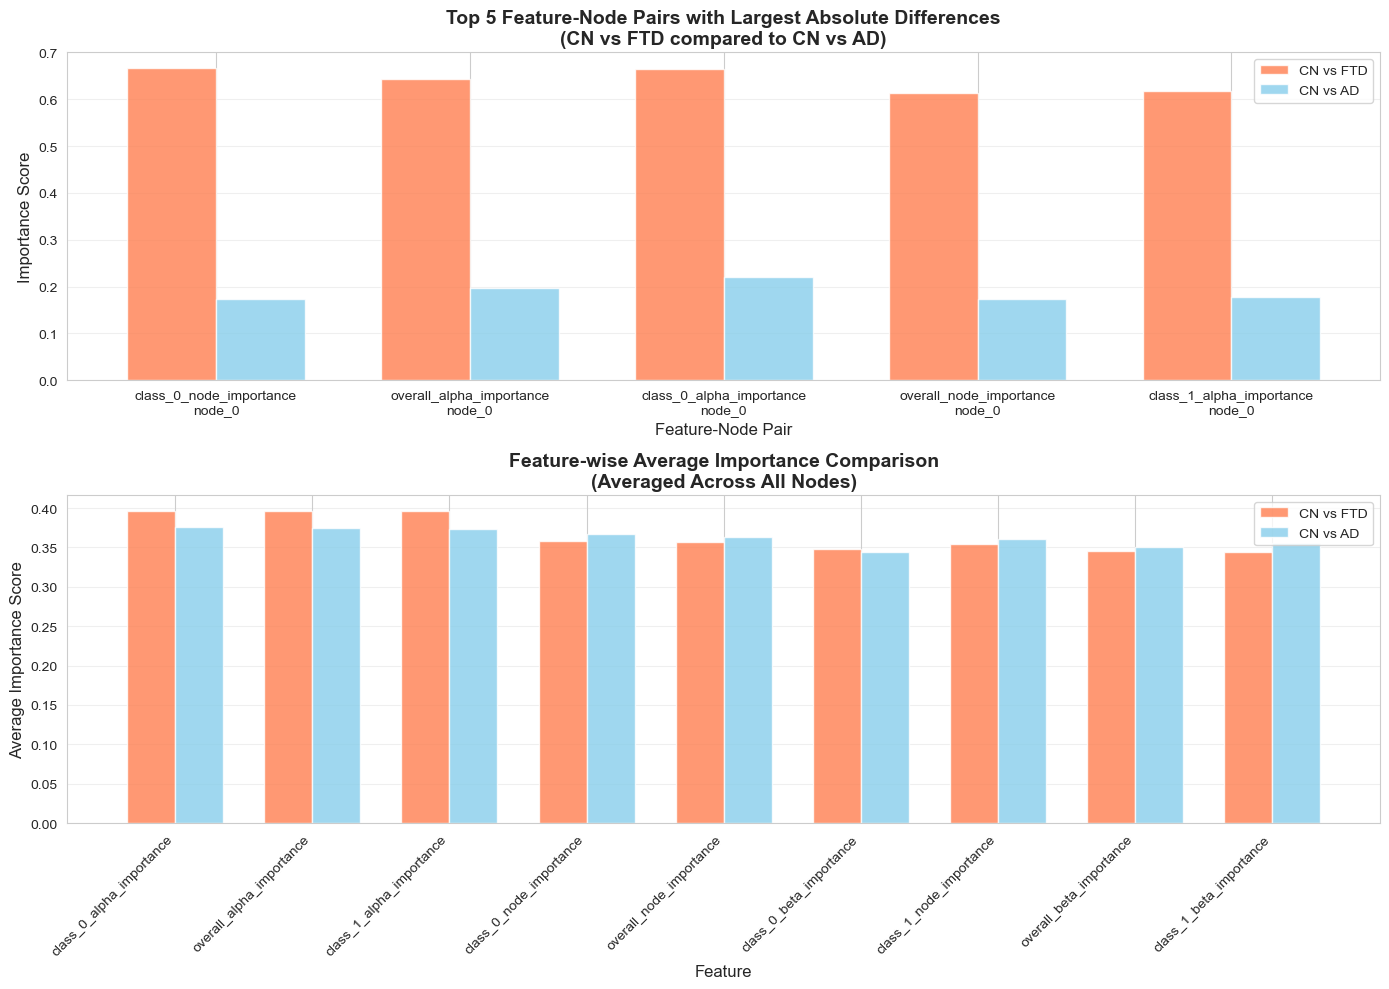

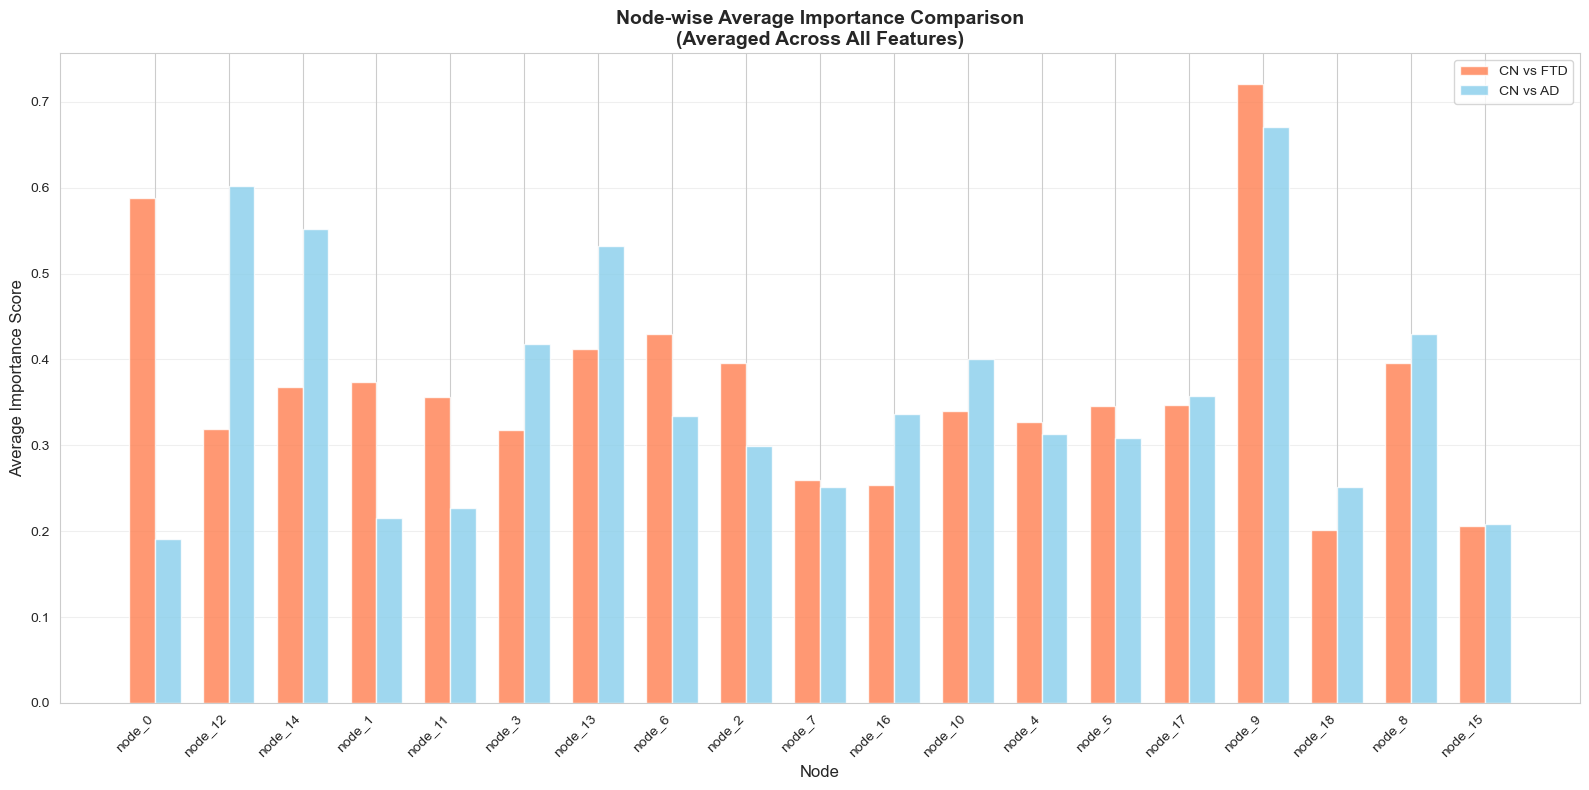

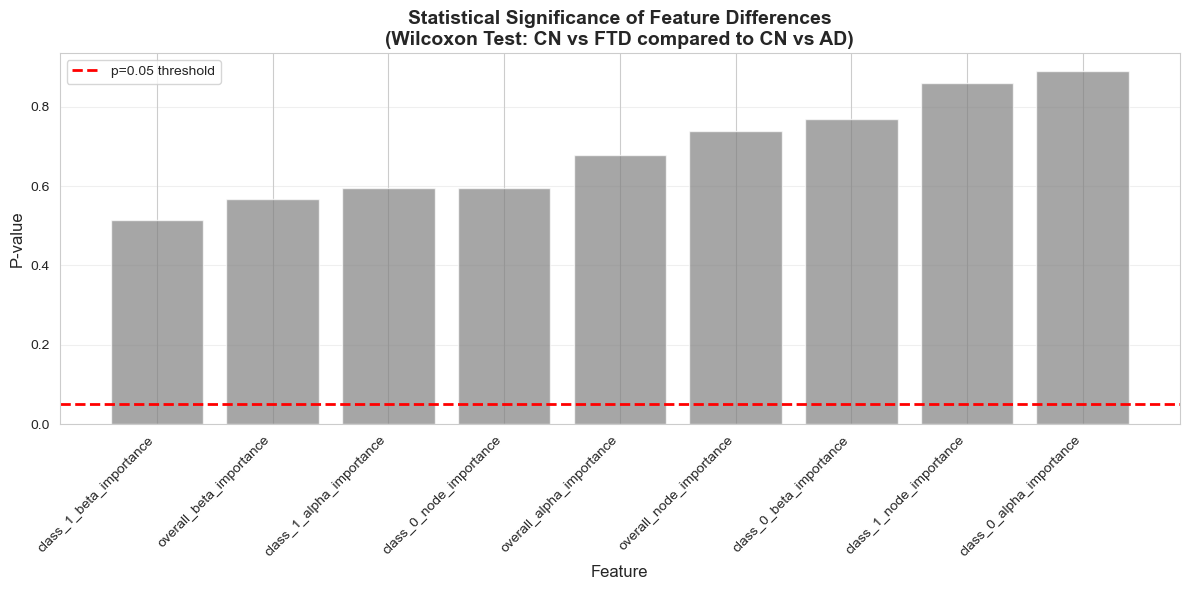

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# Base directory
base_dir = r'C:\Users\fathi\Desktop\Rest_eeg_ds004504-download\xai_saliency\xai_saliency_allruns'

# Load the averaged data
# Group 1 (class1): Class0 = CN, Class1 = FTD
# Group 2 (class2): Class0 = CN, Class1 = AD
class1_avg = pd.read_csv(os.path.join(base_dir, "class1_averaged.csv"), index_col=0)
class2_avg = pd.read_csv(os.path.join(base_dir, "class2_averaged.csv"), index_col=0)

print("="*80)
print("COMPARATIVE ANALYSIS: CN vs FTD (Group 1) vs CN vs AD (Group 2)")
print("="*80)
print("\nGroup 1 (CN vs FTD):")
print(f"  Shape: {class1_avg.shape}")
print("\nGroup 2 (CN vs AD):")
print(f"  Shape: {class2_avg.shape}")
print()

# Calculate absolute difference
diff = np.abs(class1_avg - class2_avg)

# Calculate relative difference (percentage)
mean_vals = (class1_avg + class2_avg) / 2
rel_diff = (np.abs(class1_avg - class2_avg) / (mean_vals + 1e-10)) * 100

print("="*80)
print("TOP 5 LARGEST ABSOLUTE DIFFERENCES")
print("="*80)

# Flatten the difference matrix to find top differences
diff_flat = diff.stack().sort_values(ascending=False)
top5_abs = diff_flat.head(5)

print("\nTop 5 Feature-Node pairs with largest absolute differences:")
print("(Between CN vs FTD group and CN vs AD group)")
for i, ((feature, node), value) in enumerate(top5_abs.items(), 1):
    cn_ftd_val = class1_avg.loc[feature, node]
    cn_ad_val = class2_avg.loc[feature, node]
    print(f"{i}. {feature} @ {node}")
    print(f"   CN vs FTD: {cn_ftd_val:.6f}")
    print(f"   CN vs AD:  {cn_ad_val:.6f}")
    print(f"   Difference: {value:.6f}")
    print()

print("="*80)
print("TOP 5 LARGEST RELATIVE DIFFERENCES (Percentage)")
print("="*80)

rel_diff_flat = rel_diff.stack().sort_values(ascending=False)
top5_rel = rel_diff_flat.head(5)

print("\nTop 5 Feature-Node pairs with largest relative differences:")
for i, ((feature, node), value) in enumerate(top5_rel.items(), 1):
    cn_ftd_val = class1_avg.loc[feature, node]
    cn_ad_val = class2_avg.loc[feature, node]
    print(f"{i}. {feature} @ {node}")
    print(f"   CN vs FTD: {cn_ftd_val:.6f}")
    print(f"   CN vs AD:  {cn_ad_val:.6f}")
    print(f"   Relative Difference: {value:.2f}%")
    print()

print("="*80)
print("TOP 5 DIFFERENCES BY FEATURE (Averaged Across All Nodes)")
print("="*80)

# Average difference across all nodes for each feature
feature_avg_diff = diff.mean(axis=1).sort_values(ascending=False)
print("\nFeatures ranked by average difference across all nodes:")
for i, (feature, value) in enumerate(feature_avg_diff.items(), 1):
    cn_ftd_mean = class1_avg.loc[feature].mean()
    cn_ad_mean = class2_avg.loc[feature].mean()
    print(f"{i}. {feature}")
    print(f"   CN vs FTD (avg): {cn_ftd_mean:.6f}")
    print(f"   CN vs AD (avg):  {cn_ad_mean:.6f}")
    print(f"   Avg Difference: {value:.6f}")
    print()

print("="*80)
print("TOP 5 DIFFERENCES BY NODE (Averaged Across All Features)")
print("="*80)

# Average difference across all features for each node
node_avg_diff = diff.mean(axis=0).sort_values(ascending=False)
print("\nNodes ranked by average difference across all features:")
for i, (node, value) in enumerate(node_avg_diff.head(5).items(), 1):
    cn_ftd_mean = class1_avg[node].mean()
    cn_ad_mean = class2_avg[node].mean()
    print(f"{i}. {node}")
    print(f"   CN vs FTD (avg): {cn_ftd_mean:.6f}")
    print(f"   CN vs AD (avg):  {cn_ad_mean:.6f}")
    print(f"   Avg Difference: {value:.6f}")
    print()

# Statistical tests
print("="*80)
print("STATISTICAL TESTS (Feature-wise comparison)")
print("="*80)
print("\nWilcoxon Signed-Rank Test for each feature (across all nodes):")
print("H0: No difference between CN vs FTD group and CN vs AD group\n")

statistical_results = []
for feature in class1_avg.index:
    cn_ftd_vals = class1_avg.loc[feature].values
    cn_ad_vals = class2_avg.loc[feature].values
    
    # Wilcoxon signed-rank test
    statistic, pvalue = stats.wilcoxon(cn_ftd_vals, cn_ad_vals)
    
    # Effect size (Cohen's d)
    mean_diff = np.mean(cn_ftd_vals - cn_ad_vals)
    pooled_std = np.sqrt((np.std(cn_ftd_vals)**2 + np.std(cn_ad_vals)**2) / 2)
    cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
    
    statistical_results.append({
        'feature': feature,
        'statistic': statistic,
        'p_value': pvalue,
        'cohens_d': cohens_d,
        'significant': 'Yes' if pvalue < 0.05 else 'No'
    })
    
    print(f"{feature}:")
    print(f"  Statistic: {statistic:.4f}")
    print(f"  P-value: {pvalue:.4f} {'***' if pvalue < 0.001 else '**' if pvalue < 0.01 else '*' if pvalue < 0.05 else 'ns'}")
    print(f"  Cohen's d: {cohens_d:.4f}")
    print(f"  Significant: {statistical_results[-1]['significant']}")
    print()

# Save statistical results
stats_df = pd.DataFrame(statistical_results)
stats_df.to_csv(os.path.join(base_dir, "statistical_comparison_CN_FTD_vs_CN_AD.csv"), index=False)
print(f"✔ Statistical results saved to: statistical_comparison_CN_FTD_vs_CN_AD.csv")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

# 1. Heatmap of absolute differences
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Difference heatmap
sns.heatmap(diff, annot=False, cmap='RdYlBu_r', center=0, 
            cbar_kws={'label': 'Absolute Difference'}, ax=axes[0, 0])
axes[0, 0].set_title('Absolute Difference\n(|CN vs FTD - CN vs AD|)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Nodes', fontsize=12)
axes[0, 0].set_ylabel('Features', fontsize=12)

# Group 1 (CN vs FTD) heatmap
sns.heatmap(class1_avg, annot=False, cmap='YlOrRd', 
            cbar_kws={'label': 'Importance Score'}, ax=axes[0, 1])
axes[0, 1].set_title('Group 1: CN vs FTD\nAveraged Importance', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Nodes', fontsize=12)
axes[0, 1].set_ylabel('Features', fontsize=12)

# Group 2 (CN vs AD) heatmap
sns.heatmap(class2_avg, annot=False, cmap='YlGnBu', 
            cbar_kws={'label': 'Importance Score'}, ax=axes[1, 0])
axes[1, 0].set_title('Group 2: CN vs AD\nAveraged Importance', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Nodes', fontsize=12)
axes[1, 0].set_ylabel('Features', fontsize=12)

# Relative difference heatmap
sns.heatmap(rel_diff, annot=False, cmap='RdYlBu_r', 
            cbar_kws={'label': 'Relative Difference (%)'}, ax=axes[1, 1])
axes[1, 1].set_title('Relative Difference (%)\n(CN vs FTD compared to CN vs AD)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Nodes', fontsize=12)
axes[1, 1].set_ylabel('Features', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'comparison_heatmaps_CN_FTD_AD.png'), dpi=300, bbox_inches='tight')
print("✔ Saved: comparison_heatmaps_CN_FTD_AD.png")

# 2. Bar plot of top differences
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top 5 absolute differences
top5_abs_df = pd.DataFrame({
    'Feature-Node': [f"{f}\n{n}" for f, n in top5_abs.index],
    'CN vs FTD': [class1_avg.loc[f, n] for f, n in top5_abs.index],
    'CN vs AD': [class2_avg.loc[f, n] for f, n in top5_abs.index]
})

x_pos = np.arange(len(top5_abs_df))
width = 0.35
axes[0].bar(x_pos - width/2, top5_abs_df['CN vs FTD'], width, label='CN vs FTD', alpha=0.8, color='coral')
axes[0].bar(x_pos + width/2, top5_abs_df['CN vs AD'], width, label='CN vs AD', alpha=0.8, color='skyblue')
axes[0].set_xlabel('Feature-Node Pair', fontsize=12)
axes[0].set_ylabel('Importance Score', fontsize=12)
axes[0].set_title('Top 5 Feature-Node Pairs with Largest Absolute Differences\n(CN vs FTD compared to CN vs AD)', 
                   fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(top5_abs_df['Feature-Node'], rotation=0, ha='center')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Feature-wise average comparison
feature_comparison = pd.DataFrame({
    'CN vs FTD': class1_avg.mean(axis=1),
    'CN vs AD': class2_avg.mean(axis=1),
    'Difference': feature_avg_diff
}).sort_values('Difference', ascending=False)

x_pos = np.arange(len(feature_comparison))
width = 0.35
axes[1].bar(x_pos - width/2, feature_comparison['CN vs FTD'], width, label='CN vs FTD', alpha=0.8, color='coral')
axes[1].bar(x_pos + width/2, feature_comparison['CN vs AD'], width, label='CN vs AD', alpha=0.8, color='skyblue')
axes[1].set_xlabel('Feature', fontsize=12)
axes[1].set_ylabel('Average Importance Score', fontsize=12)
axes[1].set_title('Feature-wise Average Importance Comparison\n(Averaged Across All Nodes)', 
                   fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(feature_comparison.index, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'comparison_barplots_CN_FTD_AD.png'), dpi=300, bbox_inches='tight')
print("✔ Saved: comparison_barplots_CN_FTD_AD.png")

# 3. Node-wise comparison
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

node_comparison = pd.DataFrame({
    'CN vs FTD': class1_avg.mean(axis=0),
    'CN vs AD': class2_avg.mean(axis=0),
    'Difference': node_avg_diff
}).sort_values('Difference', ascending=False)

x_pos = np.arange(len(node_comparison))
width = 0.35
ax.bar(x_pos - width/2, node_comparison['CN vs FTD'], width, label='CN vs FTD', alpha=0.8, color='coral')
ax.bar(x_pos + width/2, node_comparison['CN vs AD'], width, label='CN vs AD', alpha=0.8, color='skyblue')
ax.set_xlabel('Node', fontsize=12)
ax.set_ylabel('Average Importance Score', fontsize=12)
ax.set_title('Node-wise Average Importance Comparison\n(Averaged Across All Features)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(node_comparison.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'comparison_nodes_CN_FTD_AD.png'), dpi=300, bbox_inches='tight')
print("✔ Saved: comparison_nodes_CN_FTD_AD.png")

# 4. P-value visualization
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

stats_df_sorted = stats_df.sort_values('p_value')
colors = ['red' if p < 0.05 else 'gray' for p in stats_df_sorted['p_value']]

ax.bar(range(len(stats_df_sorted)), stats_df_sorted['p_value'], color=colors, alpha=0.7)
ax.axhline(y=0.05, color='red', linestyle='--', label='p=0.05 threshold', linewidth=2)
ax.set_xlabel('Feature', fontsize=12)
ax.set_ylabel('P-value', fontsize=12)
ax.set_title('Statistical Significance of Feature Differences\n(Wilcoxon Test: CN vs FTD compared to CN vs AD)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(range(len(stats_df_sorted)))
ax.set_xticklabels(stats_df_sorted['feature'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'statistical_significance_CN_FTD_AD.png'), dpi=300, bbox_inches='tight')
print("✔ Saved: statistical_significance_CN_FTD_AD.png")

print("\n" + "="*80)
print("ANALYSIS COMPLETE ✓")
print("="*80)
print("\nGenerated files:")
print("  • statistical_comparison_CN_FTD_vs_CN_AD.csv - Statistical test results")
print("  • comparison_heatmaps_CN_FTD_AD.png - Heatmaps showing differences")
print("  • comparison_barplots_CN_FTD_AD.png - Top differences and feature comparison")
print("  • comparison_nodes_CN_FTD_AD.png - Node-wise comparison")
print("  • statistical_significance_CN_FTD_AD.png - P-values visualization")
print("\nNote:")
print("  Group 1: CN (Class 0) vs FTD (Class 1)")
print("  Group 2: CN (Class 0) vs AD (Class 1)")

In [ ]:
import sys
print(sys.version)

In [2]:
"""
Channel Index to Electrode Name Mapping
Based on your graph generation code
"""

# Channel order from your ALL_CHANNELS list (indices 0-18)
ALL_CHANNELS = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2',
                'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']

# Lobe mapping according to 10-20 system
LOBE_MAPPING = {
    "Frontal": ["Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8"],
    "Central": ["C3", "Cz", "C4"],
    "Temporal": ["T3", "T4", "T5", "T6"],
    "Parietal": ["P3", "Pz", "P4"],
    "Occipital": ["O1", "O2"]
}

# Create index to channel mapping
INDEX_TO_CHANNEL = {idx: ch for idx, ch in enumerate(ALL_CHANNELS)}

# Create channel to lobe mapping
CHANNEL_TO_LOBE = {}
for lobe, channels in LOBE_MAPPING.items():
    for ch in channels:
        CHANNEL_TO_LOBE[ch] = lobe

# Create index to lobe mapping
INDEX_TO_LOBE = {idx: CHANNEL_TO_LOBE[ch] for idx, ch in enumerate(ALL_CHANNELS)}

# Print comprehensive mapping table
print("\n" + "="*70)
print("COMPLETE CHANNEL MAPPING TABLE")
print("="*70)
print(f"{'Index':<8} {'Channel':<10} {'Lobe':<12} {'Position in Lobe'}")
print("-"*70)

for lobe in ["Frontal", "Central", "Temporal", "Parietal", "Occipital"]:
    lobe_channels = LOBE_MAPPING[lobe]
    print(f"\n{lobe.upper()} LOBE:")
    for pos, ch in enumerate(lobe_channels, 1):
        idx = ALL_CHANNELS.index(ch)
        print(f"  {idx:<8} {ch:<10} {lobe:<12} {pos}/{len(lobe_channels)}")

print("\n" + "="*70)
print("SEQUENTIAL ORDER (as stored in your data):")
print("="*70)
for idx, ch in enumerate(ALL_CHANNELS):
    lobe = CHANNEL_TO_LOBE[ch]
    print(f"Index {idx:2d}: {ch:4s} -> {lobe:12s} lobe")

print("\n" + "="*70)
print("LOBE-WISE GROUPED ORDER:")
print("="*70)
ordered_by_lobe = []
for lobe in ["Frontal", "Central", "Temporal", "Parietal", "Occipital"]:
    channels = LOBE_MAPPING[lobe]
    ordered_by_lobe.extend(channels)
    indices = [ALL_CHANNELS.index(ch) for ch in channels]
    print(f"\n{lobe:12s}: {', '.join(channels)}")
    print(f"{'':12s}  Indices: {indices}")

print("\n" + "="*70)
print("SUMMARY:")
print("="*70)
print(f"Total channels: {len(ALL_CHANNELS)}")
print(f"Frontal:   {len(LOBE_MAPPING['Frontal'])} channels")
print(f"Central:   {len(LOBE_MAPPING['Central'])} channels")
print(f"Temporal:  {len(LOBE_MAPPING['Temporal'])} channels")
print(f"Parietal:  {len(LOBE_MAPPING['Parietal'])} channels")
print(f"Occipital: {len(LOBE_MAPPING['Occipital'])} channels")
print("="*70)

# Save mappings to file
import json

mapping_data = {
    "all_channels": ALL_CHANNELS,
    "lobe_mapping": LOBE_MAPPING,
    "index_to_channel": INDEX_TO_CHANNEL,
    "channel_to_lobe": CHANNEL_TO_LOBE,
    "index_to_lobe": INDEX_TO_LOBE
}

with open("channel_mapping.json", "w") as f:
    json.dump(mapping_data, f, indent=2)

print("\n✓ Mapping saved to: channel_mapping.json")


COMPLETE CHANNEL MAPPING TABLE
Index    Channel    Lobe         Position in Lobe
----------------------------------------------------------------------

FRONTAL LOBE:
  0        Fp1        Frontal      1/7
  1        Fp2        Frontal      2/7
  10       F7         Frontal      3/7
  2        F3         Frontal      4/7
  16       Fz         Frontal      5/7
  3        F4         Frontal      6/7
  11       F8         Frontal      7/7

CENTRAL LOBE:
  4        C3         Central      1/3
  17       Cz         Central      2/3
  5        C4         Central      3/3

TEMPORAL LOBE:
  12       T3         Temporal     1/4
  13       T4         Temporal     2/4
  14       T5         Temporal     3/4
  15       T6         Temporal     4/4

PARIETAL LOBE:
  6        P3         Parietal     1/3
  18       Pz         Parietal     2/3
  7        P4         Parietal     3/3

OCCIPITAL LOBE:
  8        O1         Occipital    1/2
  9        O2         Occipital    2/2

SEQUENTIAL ORDER (as store

COMPARATIVE ANALYSIS: FTD vs AD

FTD Group:
  Shape: (9, 19)

AD Group:
  Shape: (9, 19)

TOP 5 LARGEST ABSOLUTE DIFFERENCES

Top 5 Feature-Node pairs with largest absolute differences:
(Between FTD and AD groups)
1. class_0_node_importance @ node_0
   FTD: 0.667169
   AD:  0.174213
   Difference: 0.492955

2. overall_alpha_importance @ node_0
   FTD: 0.642870
   AD:  0.196511
   Difference: 0.446359

3. class_0_alpha_importance @ node_0
   FTD: 0.663527
   AD:  0.220005
   Difference: 0.443522

4. overall_node_importance @ node_0
   FTD: 0.613332
   AD:  0.172745
   Difference: 0.440587

5. class_1_alpha_importance @ node_0
   FTD: 0.616824
   AD:  0.177585
   Difference: 0.439238

TOP 5 LARGEST RELATIVE DIFFERENCES (Percentage)

Top 5 Feature-Node pairs with largest relative differences:
1. class_0_node_importance @ node_0
   FTD: 0.667169
   AD:  0.174213
   Relative Difference: 117.18%

2. overall_node_importance @ node_0
   FTD: 0.613332
   AD:  0.172745
   Relative Difference: 11

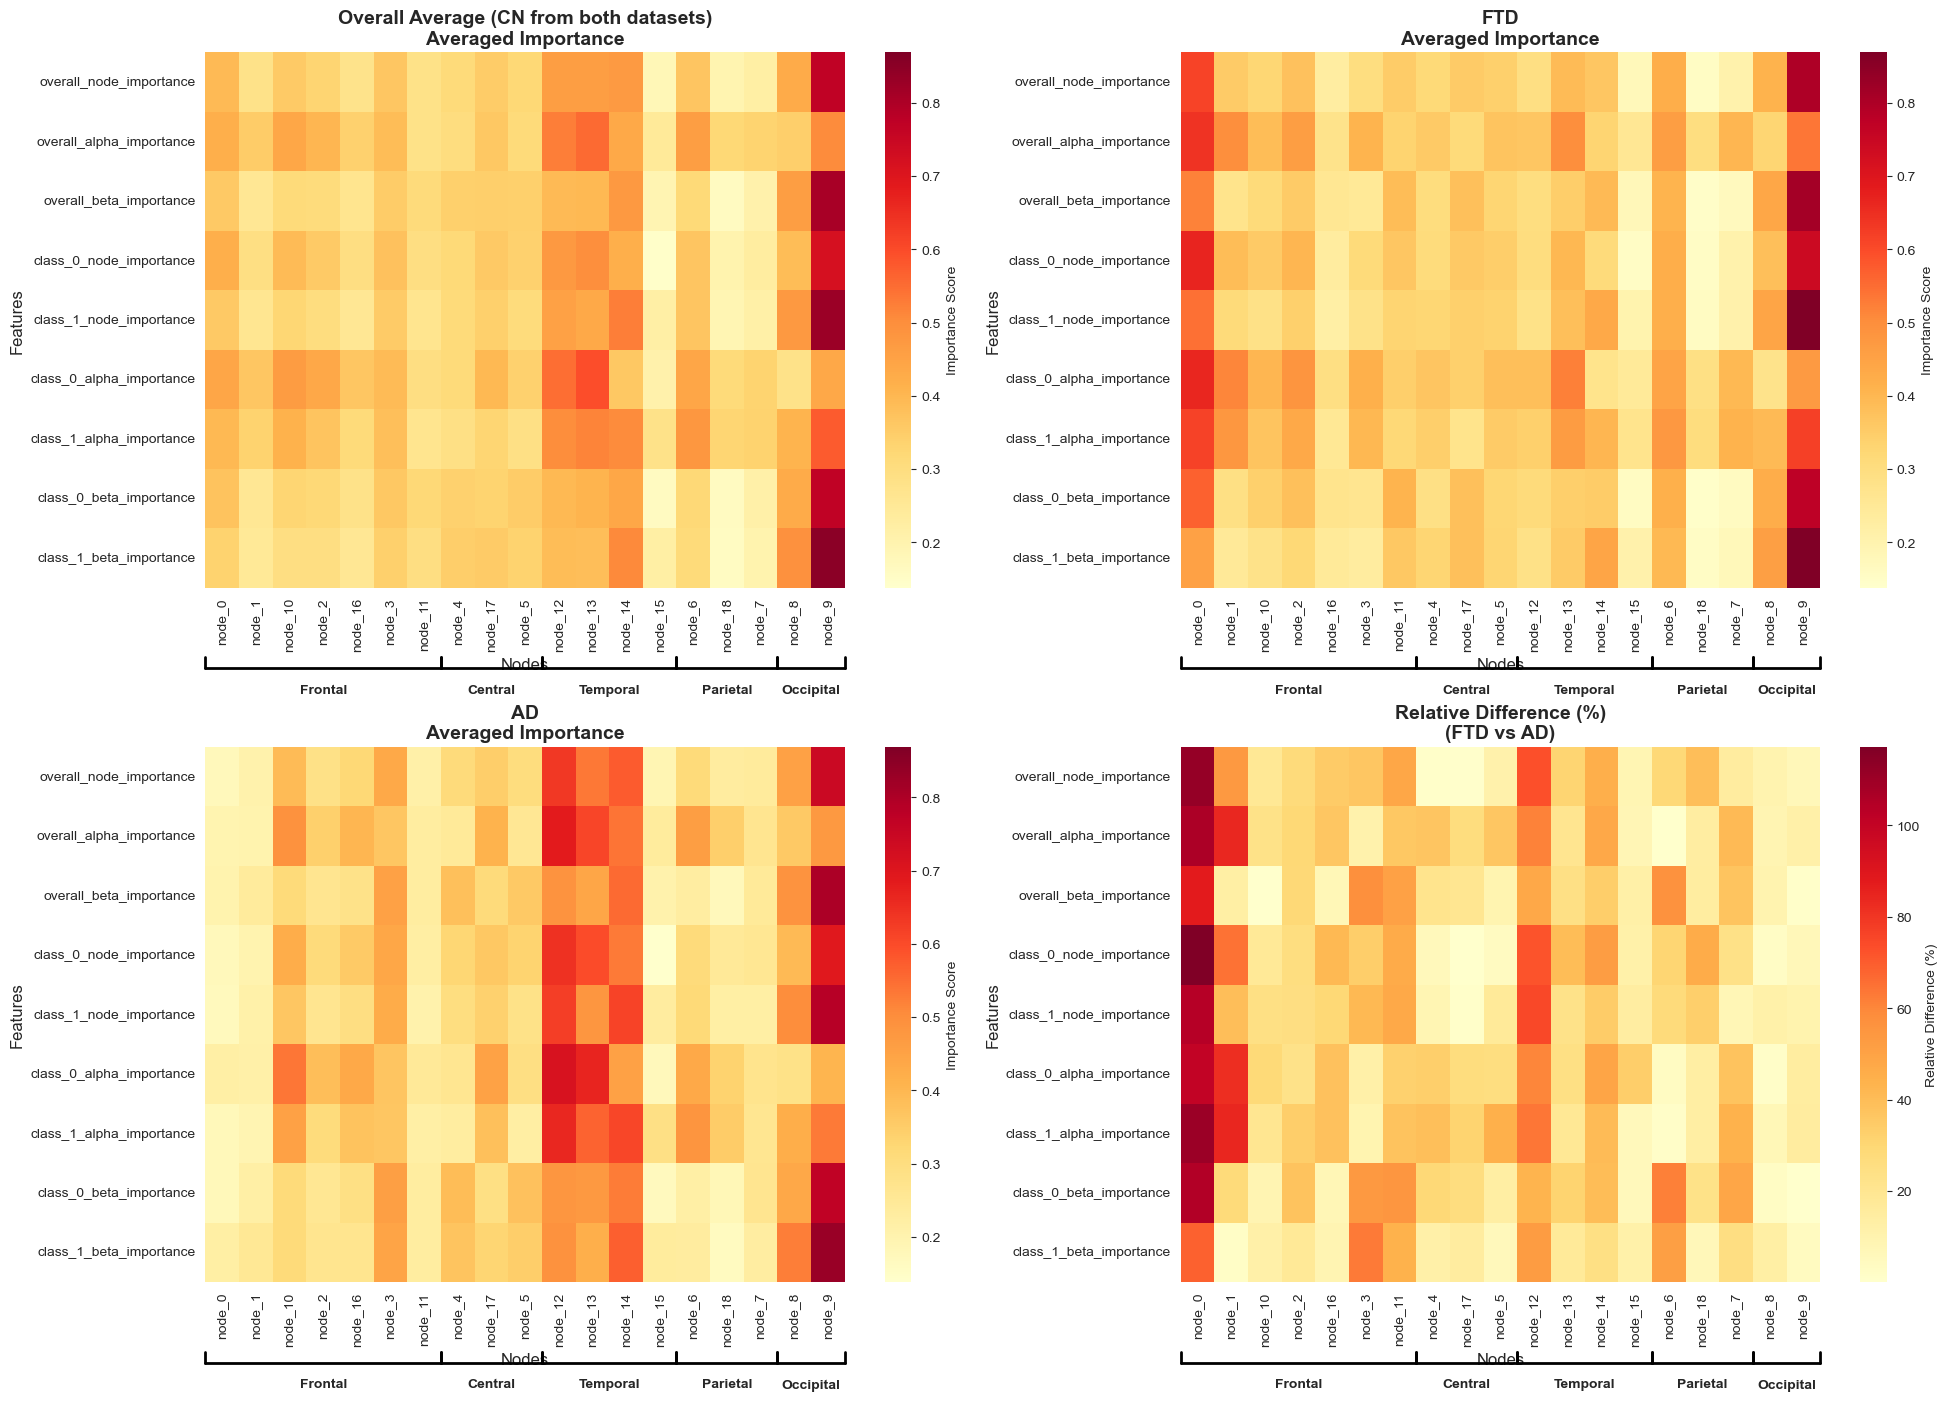

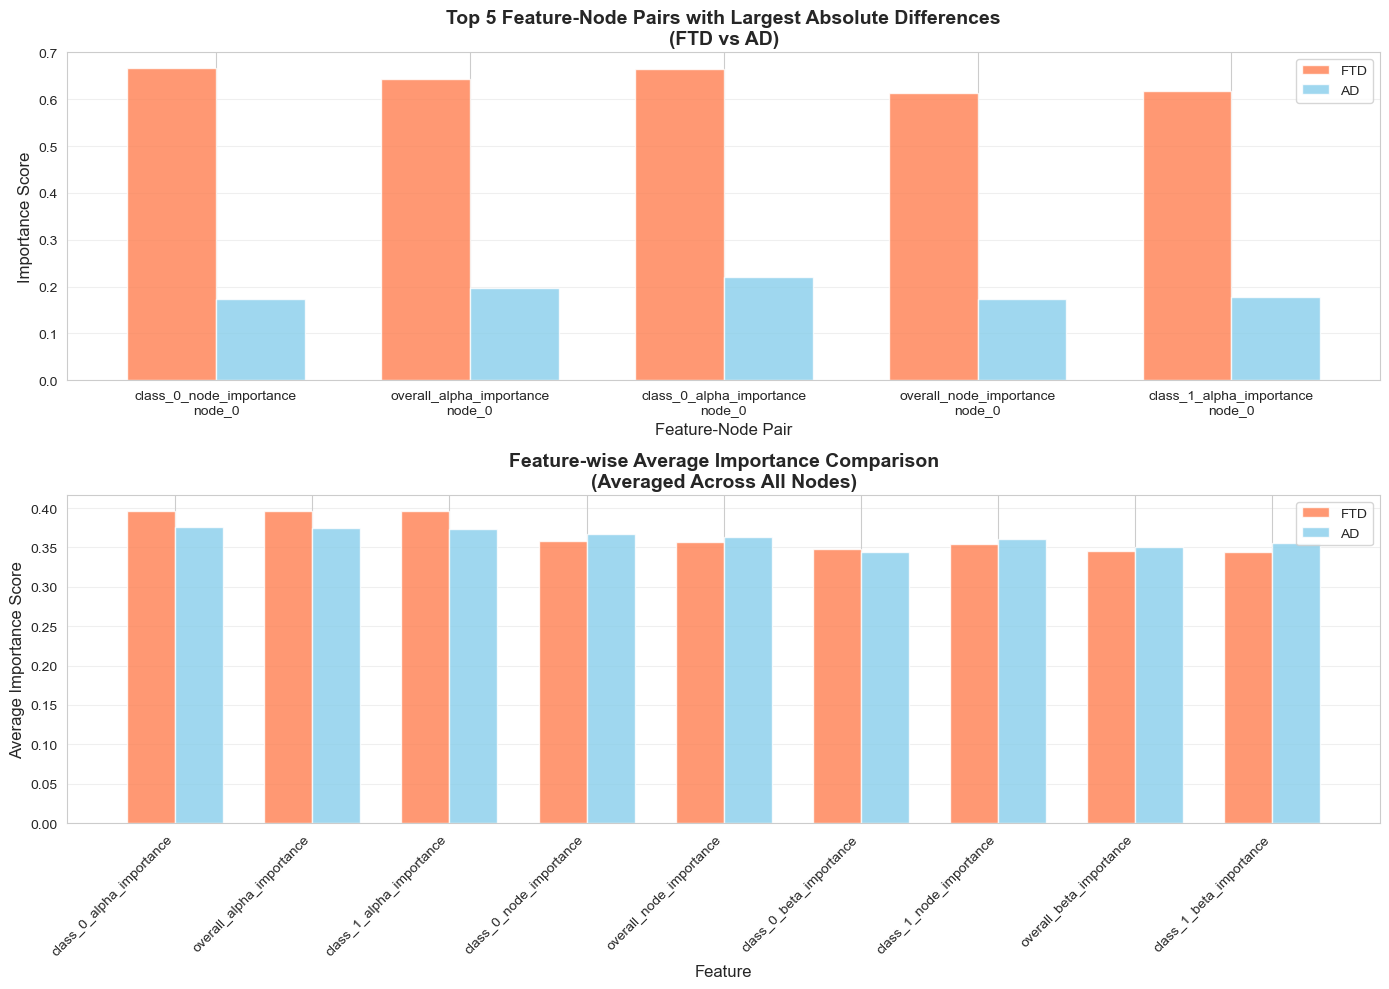

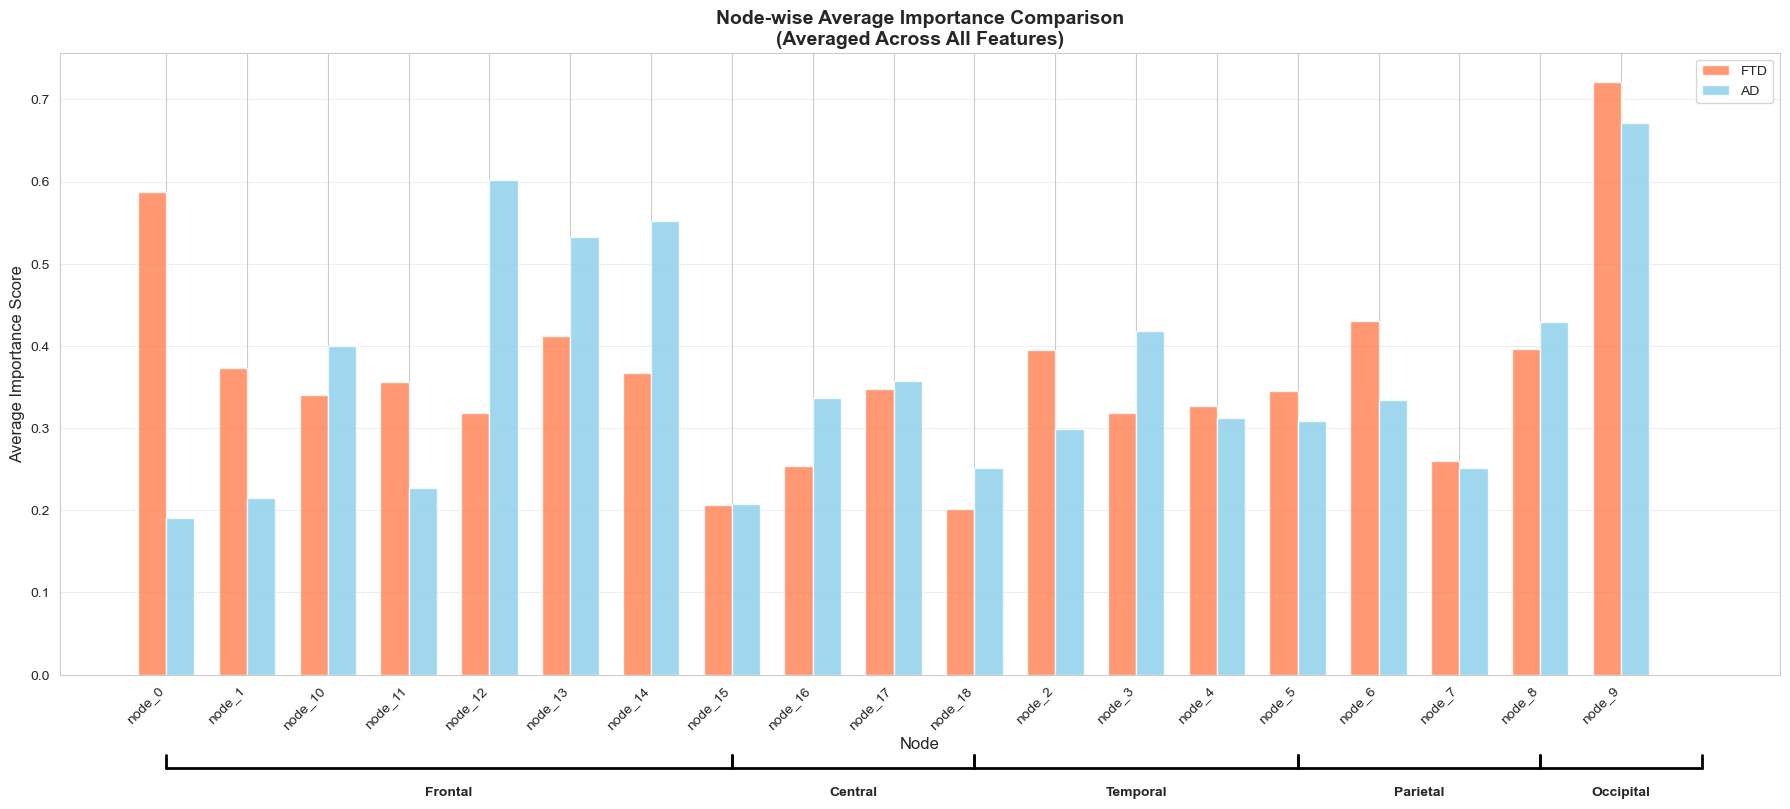

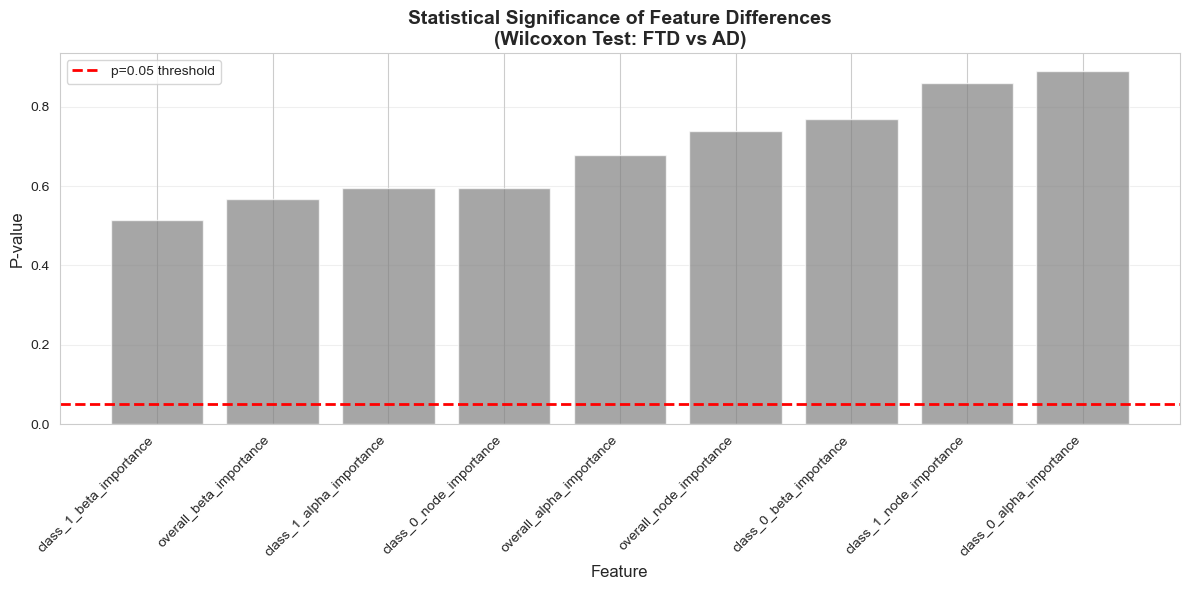

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.patches import Rectangle

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# Base directory
base_dir = r'C:\Users\fathi\Desktop\Rest_eeg_ds004504-download\xai_saliency\xai_saliency_allruns'

# Load the averaged data
# class1_averaged.csv contains FTD data
# class2_averaged.csv contains AD data
class1_avg = pd.read_csv(os.path.join(base_dir, "class1_averaged.csv"), index_col=0)
class2_avg = pd.read_csv(os.path.join(base_dir, "class2_averaged.csv"), index_col=0)

print("="*80)
print("COMPARATIVE ANALYSIS: FTD vs AD")
print("="*80)
print("\nFTD Group:")
print(f"  Shape: {class1_avg.shape}")
print("\nAD Group:")
print(f"  Shape: {class2_avg.shape}")
print()

# Define node-to-lobe mapping
node_names = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 
              'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']

lobe_mapping = {
    'Frontal': [0, 1, 10, 2, 16, 3, 11],      # Fp1, Fp2, F7, F3, Fz, F4, F8
    'Central': [4, 17, 5],                     # C3, Cz, C4
    'Temporal': [12, 13, 14, 15],              # T3, T4, T5, T6
    'Parietal': [6, 18, 7],                    # P3, Pz, P4
    'Occipital': [8, 9]                        # O1, O2
}

# Create ordered node indices
ordered_indices = []
lobe_boundaries = {}
current_pos = 0

for lobe, indices in lobe_mapping.items():
    ordered_indices.extend(indices)
    lobe_boundaries[lobe] = (current_pos, current_pos + len(indices) - 1)
    current_pos += len(indices)

# Reorder columns based on lobe grouping
ordered_columns = [class1_avg.columns[i] for i in ordered_indices]
class1_avg_ordered = class1_avg[ordered_columns]
class2_avg_ordered = class2_avg[ordered_columns]

# Calculate overall average (CN overall)
overall_avg = (class1_avg_ordered + class2_avg_ordered) / 2

# Calculate absolute difference
diff = np.abs(class1_avg_ordered - class2_avg_ordered)

# Calculate relative difference (percentage)
mean_vals = (class1_avg_ordered + class2_avg_ordered) / 2
rel_diff = (np.abs(class1_avg_ordered - class2_avg_ordered) / (mean_vals + 1e-10)) * 100

print("="*80)
print("TOP 5 LARGEST ABSOLUTE DIFFERENCES")
print("="*80)

# Flatten the difference matrix to find top differences
diff_flat = diff.stack().sort_values(ascending=False)
top5_abs = diff_flat.head(5)

print("\nTop 5 Feature-Node pairs with largest absolute differences:")
print("(Between FTD and AD groups)")
for i, ((feature, node), value) in enumerate(top5_abs.items(), 1):
    ftd_val = class1_avg_ordered.loc[feature, node]
    ad_val = class2_avg_ordered.loc[feature, node]
    print(f"{i}. {feature} @ {node}")
    print(f"   FTD: {ftd_val:.6f}")
    print(f"   AD:  {ad_val:.6f}")
    print(f"   Difference: {value:.6f}")
    print()

print("="*80)
print("TOP 5 LARGEST RELATIVE DIFFERENCES (Percentage)")
print("="*80)

rel_diff_flat = rel_diff.stack().sort_values(ascending=False)
top5_rel = rel_diff_flat.head(5)

print("\nTop 5 Feature-Node pairs with largest relative differences:")
for i, ((feature, node), value) in enumerate(top5_rel.items(), 1):
    ftd_val = class1_avg_ordered.loc[feature, node]
    ad_val = class2_avg_ordered.loc[feature, node]
    print(f"{i}. {feature} @ {node}")
    print(f"   FTD: {ftd_val:.6f}")
    print(f"   AD:  {ad_val:.6f}")
    print(f"   Relative Difference: {value:.2f}%")
    print()

print("="*80)
print("TOP 5 DIFFERENCES BY FEATURE (Averaged Across All Nodes)")
print("="*80)

# Average difference across all nodes for each feature
feature_avg_diff = diff.mean(axis=1).sort_values(ascending=False)
print("\nFeatures ranked by average difference across all nodes:")
for i, (feature, value) in enumerate(feature_avg_diff.items(), 1):
    ftd_mean = class1_avg_ordered.loc[feature].mean()
    ad_mean = class2_avg_ordered.loc[feature].mean()
    print(f"{i}. {feature}")
    print(f"   FTD (avg): {ftd_mean:.6f}")
    print(f"   AD (avg):  {ad_mean:.6f}")
    print(f"   Avg Difference: {value:.6f}")
    print()

print("="*80)
print("TOP 5 DIFFERENCES BY NODE (Averaged Across All Features)")
print("="*80)

# Average difference across all features for each node
node_avg_diff = diff.mean(axis=0).sort_values(ascending=False)
print("\nNodes ranked by average difference across all features:")
for i, (node, value) in enumerate(node_avg_diff.head(5).items(), 1):
    ftd_mean = class1_avg_ordered[node].mean()
    ad_mean = class2_avg_ordered[node].mean()
    print(f"{i}. {node}")
    print(f"   FTD (avg): {ftd_mean:.6f}")
    print(f"   AD (avg):  {ad_mean:.6f}")
    print(f"   Avg Difference: {value:.6f}")
    print()

# Statistical tests
print("="*80)
print("STATISTICAL TESTS (Feature-wise comparison)")
print("="*80)
print("\nWilcoxon Signed-Rank Test for each feature (across all nodes):")
print("H0: No difference between FTD group and AD group\n")

statistical_results = []
for feature in class1_avg_ordered.index:
    ftd_vals = class1_avg_ordered.loc[feature].values
    ad_vals = class2_avg_ordered.loc[feature].values
    
    # Wilcoxon signed-rank test
    statistic, pvalue = stats.wilcoxon(ftd_vals, ad_vals)
    
    # Effect size (Cohen's d)
    mean_diff = np.mean(ftd_vals - ad_vals)
    pooled_std = np.sqrt((np.std(ftd_vals)**2 + np.std(ad_vals)**2) / 2)
    cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
    
    statistical_results.append({
        'feature': feature,
        'statistic': statistic,
        'p_value': pvalue,
        'cohens_d': cohens_d,
        'significant': 'Yes' if pvalue < 0.05 else 'No'
    })
    
    print(f"{feature}:")
    print(f"  Statistic: {statistic:.4f}")
    print(f"  P-value: {pvalue:.4f} {'***' if pvalue < 0.001 else '**' if pvalue < 0.01 else '*' if pvalue < 0.05 else 'ns'}")
    print(f"  Cohen's d: {cohens_d:.4f}")
    print(f"  Significant: {statistical_results[-1]['significant']}")
    print()

# Save statistical results
stats_df = pd.DataFrame(statistical_results)
stats_df.to_csv(os.path.join(base_dir, "statistical_comparison_FTD_vs_AD.csv"), index=False)
print(f"✔ Statistical results saved to: statistical_comparison_FTD_vs_AD.csv")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

# Helper function to add lobe brackets
def add_lobe_brackets(ax, lobe_boundaries, y_position=-0.15):
    """Add brackets under the heatmap to show lobe groupings"""
    trans = ax.get_xaxis_transform()
    
    for lobe, (start, end) in lobe_boundaries.items():
        # Draw bracket line
        ax.plot([start, end + 1], [y_position, y_position], 
                color='black', linewidth=2, transform=trans, clip_on=False)
        # Draw left vertical line
        ax.plot([start, start], [y_position, y_position + 0.02], 
                color='black', linewidth=2, transform=trans, clip_on=False)
        # Draw right vertical line
        ax.plot([end + 1, end + 1], [y_position, y_position + 0.02], 
                color='black', linewidth=2, transform=trans, clip_on=False)
        # Add lobe label
        mid_point = (start + end + 1) / 2
        ax.text(mid_point, y_position - 0.03, lobe, 
                ha='center', va='top', fontsize=10, fontweight='bold',
                transform=trans, clip_on=False)

# 1. Main comparison heatmaps with consistent colormap
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Determine global min/max for consistent color scale across first 3 plots
vmin = min(overall_avg.min().min(), class1_avg_ordered.min().min(), class2_avg_ordered.min().min())
vmax = max(overall_avg.max().max(), class1_avg_ordered.max().max(), class2_avg_ordered.max().max())

# Plot 1: Overall (CN average from both groups)
sns.heatmap(overall_avg, annot=False, cmap='YlOrRd', vmin=vmin, vmax=vmax,
            cbar_kws={'label': 'Importance Score'}, ax=axes[0, 0])
axes[0, 0].set_title('Overall Average (CN from both datasets)\nAveraged Importance', 
                      fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Nodes', fontsize=12)
axes[0, 0].set_ylabel('Features', fontsize=12)
add_lobe_brackets(axes[0, 0], lobe_boundaries)

# Plot 2: FTD
sns.heatmap(class1_avg_ordered, annot=False, cmap='YlOrRd', vmin=vmin, vmax=vmax,
            cbar_kws={'label': 'Importance Score'}, ax=axes[0, 1])
axes[0, 1].set_title('FTD\nAveraged Importance', 
                      fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Nodes', fontsize=12)
axes[0, 1].set_ylabel('Features', fontsize=12)
add_lobe_brackets(axes[0, 1], lobe_boundaries)

# Plot 3: AD
sns.heatmap(class2_avg_ordered, annot=False, cmap='YlOrRd', vmin=vmin, vmax=vmax,
            cbar_kws={'label': 'Importance Score'}, ax=axes[1, 0])
axes[1, 0].set_title('AD\nAveraged Importance', 
                      fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Nodes', fontsize=12)
axes[1, 0].set_ylabel('Features', fontsize=12)
add_lobe_brackets(axes[1, 0], lobe_boundaries)

# Plot 4: Relative difference (separate colormap)
sns.heatmap(rel_diff, annot=False, cmap='YlOrRd', 
            cbar_kws={'label': 'Relative Difference (%)'}, ax=axes[1, 1])
axes[1, 1].set_title('Relative Difference (%)\n(FTD vs AD)', 
                      fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Nodes', fontsize=12)
axes[1, 1].set_ylabel('Features', fontsize=12)
add_lobe_brackets(axes[1, 1], lobe_boundaries)

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.savefig(os.path.join(base_dir, 'comparison_heatmaps_FTD_AD.png'), dpi=300, bbox_inches='tight')
print("✔ Saved: comparison_heatmaps_FTD_AD.png")

# 2. Bar plot of top differences
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top 5 absolute differences
top5_abs_df = pd.DataFrame({
    'Feature-Node': [f"{f}\n{n}" for f, n in top5_abs.index],
    'FTD': [class1_avg_ordered.loc[f, n] for f, n in top5_abs.index],
    'AD': [class2_avg_ordered.loc[f, n] for f, n in top5_abs.index]
})

x_pos = np.arange(len(top5_abs_df))
width = 0.35
axes[0].bar(x_pos - width/2, top5_abs_df['FTD'], width, label='FTD', alpha=0.8, color='coral')
axes[0].bar(x_pos + width/2, top5_abs_df['AD'], width, label='AD', alpha=0.8, color='skyblue')
axes[0].set_xlabel('Feature-Node Pair', fontsize=12)
axes[0].set_ylabel('Importance Score', fontsize=12)
axes[0].set_title('Top 5 Feature-Node Pairs with Largest Absolute Differences\n(FTD vs AD)', 
                   fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(top5_abs_df['Feature-Node'], rotation=0, ha='center')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Feature-wise average comparison
feature_comparison = pd.DataFrame({
    'FTD': class1_avg_ordered.mean(axis=1),
    'AD': class2_avg_ordered.mean(axis=1),
    'Difference': feature_avg_diff
}).sort_values('Difference', ascending=False)

x_pos = np.arange(len(feature_comparison))
width = 0.35
axes[1].bar(x_pos - width/2, feature_comparison['FTD'], width, label='FTD', alpha=0.8, color='coral')
axes[1].bar(x_pos + width/2, feature_comparison['AD'], width, label='AD', alpha=0.8, color='skyblue')
axes[1].set_xlabel('Feature', fontsize=12)
axes[1].set_ylabel('Average Importance Score', fontsize=12)
axes[1].set_title('Feature-wise Average Importance Comparison\n(Averaged Across All Nodes)', 
                   fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(feature_comparison.index, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'comparison_barplots_FTD_AD.png'), dpi=300, bbox_inches='tight')
print("✔ Saved: comparison_barplots_FTD_AD.png")

# 3. Node-wise comparison with lobe grouping
fig, ax = plt.subplots(1, 1, figsize=(18, 8))

node_comparison = pd.DataFrame({
    'FTD': class1_avg_ordered.mean(axis=0),
    'AD': class2_avg_ordered.mean(axis=0),
    'Difference': node_avg_diff
})

x_pos = np.arange(len(node_comparison))
width = 0.35
ax.bar(x_pos - width/2, node_comparison['FTD'], width, label='FTD', alpha=0.8, color='coral')
ax.bar(x_pos + width/2, node_comparison['AD'], width, label='AD', alpha=0.8, color='skyblue')
ax.set_xlabel('Node', fontsize=12)
ax.set_ylabel('Average Importance Score', fontsize=12)
ax.set_title('Node-wise Average Importance Comparison\n(Averaged Across All Features)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(node_comparison.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add lobe brackets
trans = ax.get_xaxis_transform()
y_pos = -0.15
for lobe, (start, end) in lobe_boundaries.items():
    ax.plot([start, end + 1], [y_pos, y_pos], 
            color='black', linewidth=2, transform=trans, clip_on=False)
    ax.plot([start, start], [y_pos, y_pos + 0.02], 
            color='black', linewidth=2, transform=trans, clip_on=False)
    ax.plot([end + 1, end + 1], [y_pos, y_pos + 0.02], 
            color='black', linewidth=2, transform=trans, clip_on=False)
    mid_point = (start + end + 1) / 2
    ax.text(mid_point, y_pos - 0.03, lobe, 
            ha='center', va='top', fontsize=10, fontweight='bold',
            transform=trans, clip_on=False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig(os.path.join(base_dir, 'comparison_nodes_FTD_AD.png'), dpi=300, bbox_inches='tight')
print("✔ Saved: comparison_nodes_FTD_AD.png")

# 4. P-value visualization
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

stats_df_sorted = stats_df.sort_values('p_value')
colors = ['red' if p < 0.05 else 'gray' for p in stats_df_sorted['p_value']]

ax.bar(range(len(stats_df_sorted)), stats_df_sorted['p_value'], color=colors, alpha=0.7)
ax.axhline(y=0.05, color='red', linestyle='--', label='p=0.05 threshold', linewidth=2)
ax.set_xlabel('Feature', fontsize=12)
ax.set_ylabel('P-value', fontsize=12)
ax.set_title('Statistical Significance of Feature Differences\n(Wilcoxon Test: FTD vs AD)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(range(len(stats_df_sorted)))
ax.set_xticklabels(stats_df_sorted['feature'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'statistical_significance_FTD_AD.png'), dpi=300, bbox_inches='tight')
print("✔ Saved: statistical_significance_FTD_AD.png")

print("\n" + "="*80)
print("ANALYSIS COMPLETE ✓")
print("="*80)
print("\nGenerated files:")
print("  • statistical_comparison_FTD_vs_AD.csv - Statistical test results")
print("  • comparison_heatmaps_FTD_AD.png - Heatmaps showing differences")
print("  • comparison_barplots_FTD_AD.png - Top differences and feature comparison")
print("  • comparison_nodes_FTD_AD.png - Node-wise comparison with lobe grouping")
print("  • statistical_significance_FTD_AD.png - P-values visualization")
print("\nData Source:")
print("  class1_averaged.csv = FTD (Frontotemporal Dementia)")
print("  class2_averaged.csv = AD (Alzheimer's Disease)")
print("\nLobe Grouping:")
for lobe, indices in lobe_mapping.items():
    nodes = [node_names[i] for i in indices]
    print(f"  {lobe}: {', '.join(nodes)}")